In [1]:
import numpy as np
import matplotlib.pyplot as plt 

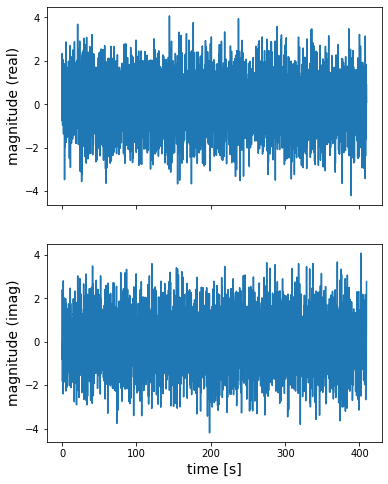

In [2]:
delta_f_ratio, time_change = 1e-5, 1200
amp_init, amp_last, f_init, f_last = 1.1, 1.1, 1.4, 3.3
sampling_rate = 10

def schottky_decay_signal(amp_init, amp_last, f_init, f_last, time_change, delta_f_ratio, sampling_rate, detector_pos_0=0, detector_pos_1=np.pi, detector_pos_2=np.pi/2):
    num = 100000
    t_range = np.arange(num) / sampling_rate
    change_before = np.where(t_range<time_change, 1, 0)
    change_after = np.where(t_range>=time_change, 1, 0)
    phase_random_0 = np.random.normal(scale=delta_f_ratio*f_init, size=num)
    phase_random_1 = np.random.normal(scale=delta_f_ratio*f_last, size=num)
    sig_0 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_0)) 
           + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_0 + 2*np.pi*f_init*time_change))
           + np.random.normal(size=num) + 1j*np.random.normal(size=num))
    sig_1 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_1)) 
           + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_1 + 2*np.pi*f_init*time_change))
           + np.random.normal(size=num) + 1j*np.random.normal(size=num))
    sig_2 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_2)) 
           + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_2 + 2*np.pi*f_init*time_change))
           + np.random.normal(size=num) + 1j*np.random.normal(size=num))
    return t_range, sig_0, sig_1, sig_2

t_range, sig_0, sig_1, sig_2 = schottky_decay_signal(amp_init=amp_init, amp_last=amp_last, f_init=f_init, f_last=f_last, time_change=time_change, delta_f_ratio=delta_f_ratio, sampling_rate=sampling_rate)

%matplotlib inline
fig, ax = plt.subplots(2,1, sharex=True, figsize=(6,8))
ax[0].plot(t_range[:4096], sig_0.real[:4096])
ax[1].plot(t_range[:4096], sig_0.imag[:4096])
ax[1].set_xlabel('time [s]', fontsize=14)
ax[0].set_ylabel('magnitude (real)', fontsize=14)
ax[1].set_ylabel('magnitude (imag)', fontsize=14)
plt.show()

In [3]:
def draw_axvlines(axs=[None], xs=[0,1], **kwargs):
    for ax in axs:
        for x in xs:
            ax.axvline(x, **kwargs)

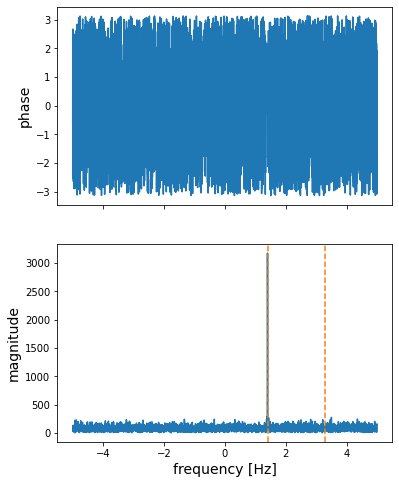

In [4]:
fft_freq = np.fft.fftshift(np.fft.fftfreq(4096, 1/sampling_rate))
fft_result_0 = np.fft.fftshift(np.fft.fft(sig_0[:4096]))
fft_result_1 = np.fft.fftshift(np.fft.fft(sig_1[:4096]))
fft_result_2 = np.fft.fftshift(np.fft.fft(sig_2[:4096]))

point_ind = np.searchsorted(fft_freq, 1.4, side='left')

%matplotlib inline
fig, ax = plt.subplots(2,1, sharex=True, figsize=(6,8))
ax[0].plot(fft_freq, np.angle(fft_result_0))
ax[1].plot(fft_freq, np.abs(fft_result_0))
draw_axvlines(axs=[ax[1]], xs=[f_init, f_last], ls='--', color='tab:orange')
ax[1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0].set_ylabel('phase', fontsize=14)
ax[1].set_ylabel('magnitude', fontsize=14)
plt.show()

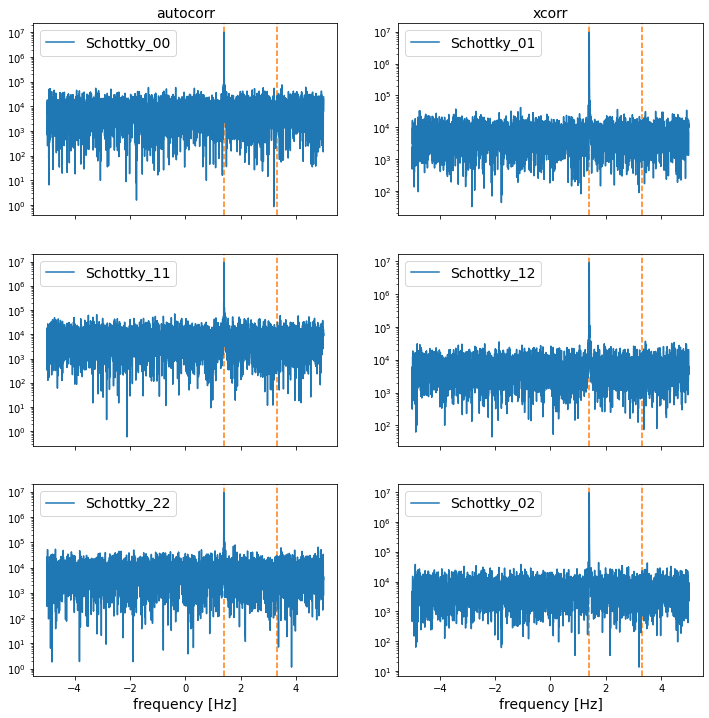

In [5]:
%matplotlib inline
fig, ax = plt.subplots(3,2, sharex=True, figsize=(12,12))
ax[0,0].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_0)), label='Schottky_00', zorder=1)
ax[0,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_1)), label='Schottky_01', zorder=1)
ax[1,0].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_1)), label='Schottky_11', zorder=1)
ax[1,1].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_2)), label='Schottky_12', zorder=1)
ax[2,0].semilogy(fft_freq, np.abs(fft_result_2*np.conjugate(fft_result_2)), label='Schottky_22', zorder=1)
ax[2,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_2)), label='Schottky_02', zorder=1)
draw_axvlines(axs=[ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0], ax[2,1]], xs=[f_init, f_last], ls='--', color='tab:orange', zorder=0)
ax[0,0].legend(fontsize=14)
ax[0,1].legend(fontsize=14)
ax[1,0].legend(fontsize=14)
ax[1,1].legend(fontsize=14)
ax[2,0].legend(fontsize=14)
ax[2,1].legend(fontsize=14)
ax[2,0].set_xlabel('frequency [Hz]', fontsize=14)
ax[2,1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0,0].set_title('autocorr', fontsize=14)
ax[0,1].set_title('xcorr', fontsize=14)
plt.show()

In [6]:
from scipy.linalg import svd

result_s = []
fft_00, fft_01, fft_02 = fft_result_0*np.conjugate(fft_result_0), fft_result_0*np.conjugate(fft_result_1), fft_result_0*np.conjugate(fft_result_2)
fft_10, fft_11, fft_12 = fft_result_1*np.conjugate(fft_result_0), fft_result_1*np.conjugate(fft_result_1), fft_result_1*np.conjugate(fft_result_2)
fft_20, fft_21, fft_22 = fft_result_2*np.conjugate(fft_result_0), fft_result_2*np.conjugate(fft_result_1), fft_result_2*np.conjugate(fft_result_2)
for i in range(len(fft_result_0)):
    s = svd(np.array([[fft_00[i], fft_01[i], fft_02[i]], [fft_10[i], fft_11[i], fft_12[i]], [fft_20[i], fft_21[i], fft_22[i]]]), compute_uv=False)
    result_s.append(s)

result_s = np.array(result_s)
print(result_s)

[[1.29619253e+04 1.30058704e-12 1.66390463e-13]
 [4.12895113e+03 3.58294480e-13 1.45442075e-13]
 [1.33841836e+03 9.00974316e-14 7.25388586e-15]
 ...
 [2.25988353e+04 1.19997458e-12 1.26866918e-13]
 [2.96952531e+04 1.26780775e-12 4.69172538e-13]
 [3.78580947e+04 1.20377061e-12 9.79386445e-13]]


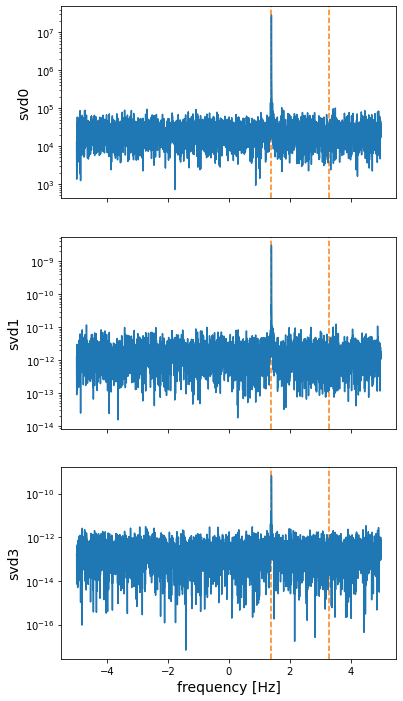

In [7]:
%matplotlib inline
fig, ax = plt.subplots(3,1, sharex=True, figsize=(6,12))
ax[0].semilogy(fft_freq, result_s[:,0], zorder=1)
ax[1].semilogy(fft_freq, result_s[:,1], zorder=1)
ax[2].semilogy(fft_freq, result_s[:,2], zorder=1)
draw_axvlines(axs=[ax[0], ax[1], ax[2]], xs=[f_init, f_last], ls='--', color='tab:orange', zorder=0)
ax[2].set_xlabel('frequency [Hz]', fontsize=14)
ax[0].set_ylabel('svd0', fontsize=14)
ax[1].set_ylabel('svd1', fontsize=14)
ax[2].set_ylabel('svd3', fontsize=14)
plt.yscale('log')
plt.show()

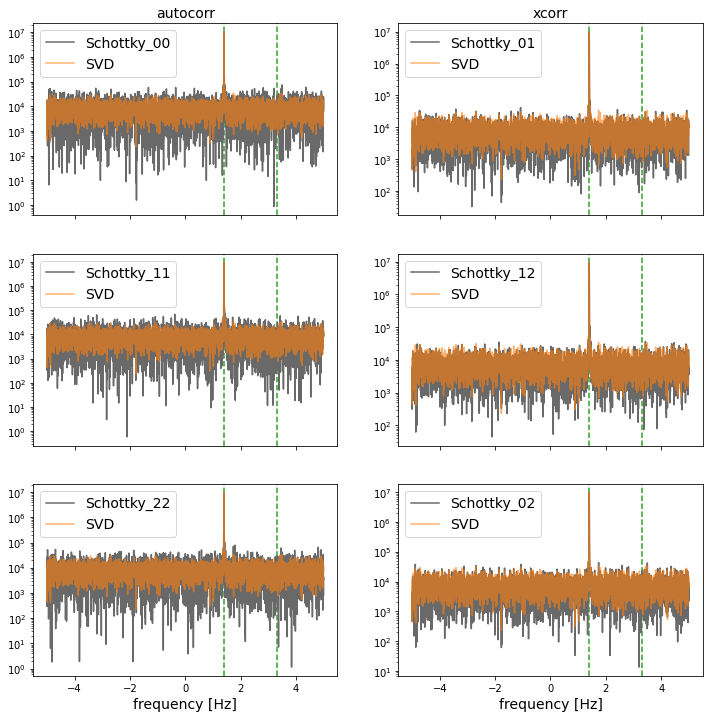

In [8]:
%matplotlib inline
fig, ax = plt.subplots(3,2, sharex=True, figsize=(12,12))
ax[0,0].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_0)), label='Schottky_00', zorder=1, color='dimgray')
ax[0,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_1)), label='Schottky_01', zorder=1, color='dimgray')
ax[1,0].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_1)), label='Schottky_11', zorder=1, color='dimgray')
ax[1,1].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_2)), label='Schottky_12', zorder=1, color='dimgray')
ax[2,0].semilogy(fft_freq, np.abs(fft_result_2*np.conjugate(fft_result_2)), label='Schottky_22', zorder=1, color='dimgray')
ax[2,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_2)), label='Schottky_02', zorder=1, color='dimgray')
ax[0,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[0,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[1,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[1,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[2,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[2,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
draw_axvlines(axs=[ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0], ax[2,1]], xs=[f_init, f_last], ls='--', color='tab:green', zorder=0)
ax[0,0].legend(fontsize=14)
ax[0,1].legend(fontsize=14)
ax[1,0].legend(fontsize=14)
ax[1,1].legend(fontsize=14)
ax[2,0].legend(fontsize=14)
ax[2,1].legend(fontsize=14)
ax[2,0].set_xlabel('frequency [Hz]', fontsize=14)
ax[2,1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0,0].set_title('autocorr', fontsize=14)
ax[0,1].set_title('xcorr', fontsize=14)
plt.show()

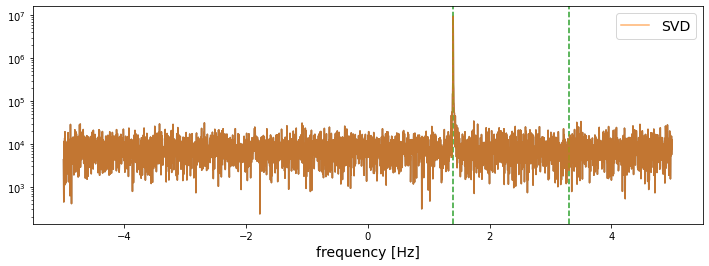

In [9]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12,4))
ax.semilogy(fft_freq, (np.abs(fft_result_0*np.conjugate(fft_result_0))+np.abs(fft_result_1*np.conjugate(fft_result_1))+np.abs(fft_result_2*np.conjugate(fft_result_2)))/3, zorder=0, color='dimgray')
ax.semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
draw_axvlines(axs=[ax], xs=[f_init, f_last], ls='--', color='tab:green', zorder=0)
ax.legend(fontsize=14)
ax.set_xlabel('frequency [Hz]', fontsize=14)
plt.show()

In [10]:
fft_0_results, fft_1_results, fft_2_results = [], [], []
svd_results = []
for i in range(4096):
    fft_0_results.append(np.fft.fftshift(np.fft.fft(sig_0[i*10:(i*10+4096)])))
    fft_1_results.append(np.fft.fftshift(np.fft.fft(sig_1[i*10:(i*10+4096)])))
    fft_2_results.append(np.fft.fftshift(np.fft.fft(sig_2[i*10:(i*10+4096)])))
    fft_00_temp, fft_01_temp, fft_02_temp = fft_0_results[-1]*np.conjugate(fft_0_results[-1]), fft_0_results[-1]*np.conjugate(fft_1_results[-1]), fft_0_results[-1]*np.conjugate(fft_2_results[-1])
    fft_10_temp, fft_11_temp, fft_12_temp = fft_1_results[-1]*np.conjugate(fft_0_results[-1]), fft_1_results[-1]*np.conjugate(fft_1_results[-1]), fft_1_results[-1]*np.conjugate(fft_2_results[-1])
    fft_20_temp, fft_21_temp, fft_22_temp = fft_2_results[-1]*np.conjugate(fft_0_results[-1]), fft_2_results[-1]*np.conjugate(fft_1_results[-1]), fft_2_results[-1]*np.conjugate(fft_2_results[-1])
    svd_temp = []
    for j in range(len(fft_00_temp)):
        s = svd(np.array([[fft_00_temp[j], fft_01_temp[j], fft_02_temp[j]], [fft_10_temp[j], fft_11_temp[j], fft_12_temp[j]], [fft_20_temp[j], fft_21_temp[j], fft_22_temp[j]]]), compute_uv=False)
        svd_temp.append(s)
    svd_results.append(svd_temp)

point_ind_0 = np.searchsorted(fft_freq, f_init, side='left')
point_ind_1 = np.searchsorted(fft_freq, f_last, side='left')

fft_0_results = (np.abs(np.array(fft_0_results))**2).T
fft_1_results = (np.abs(np.array(fft_1_results))**2).T
fft_2_results = (np.abs(np.array(fft_2_results))**2).T
svd_results = np.array(svd_results)

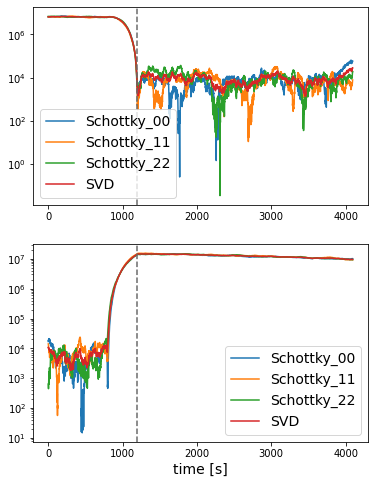

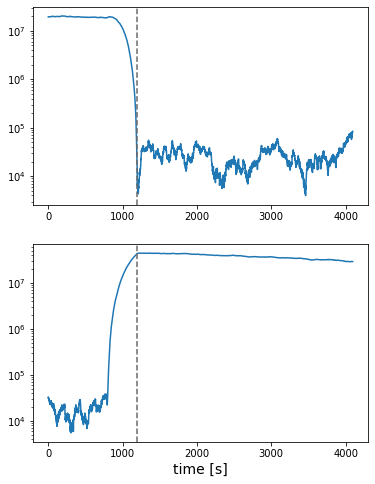

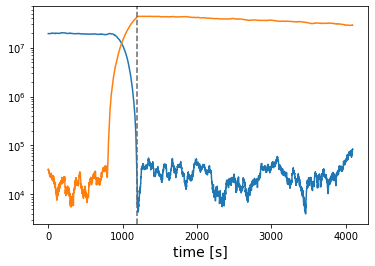

In [11]:
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].semilogy(t_range[:(4096*10):10], fft_0_results[point_ind_0,:], label='Schottky_00')
ax[0].semilogy(t_range[:(4096*10):10], fft_1_results[point_ind_0,:], label='Schottky_11')
ax[0].semilogy(t_range[:(4096*10):10], fft_2_results[point_ind_0,:], label='Schottky_22')
ax[0].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0]/3, label='SVD')
ax[0].axvline(x=time_change, color='dimgray', ls='--')
ax[1].semilogy(t_range[:(4096*10):10], fft_0_results[point_ind_1,:], label='Schottky_00')
ax[1].semilogy(t_range[:(4096*10):10], fft_1_results[point_ind_1,:], label='Schottky_11')
ax[1].semilogy(t_range[:(4096*10):10], fft_2_results[point_ind_1,:], label='Schottky_22')
ax[1].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0]/3, label='SVD')
ax[1].axvline(x=time_change, color='dimgray', ls='--')
ax[1].set_xlabel('time [s]', fontsize=14)
ax[0].legend(fontsize=14)
ax[1].legend(fontsize=14)
plt.show()

fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0])
ax[0].axvline(x=time_change, color='dimgray', ls='--')
ax[1].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0])
ax[1].axvline(x=time_change, color='dimgray', ls='--')
ax[1].set_xlabel('time [s]', fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0])
ax.semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0])
ax.axvline(x=time_change, color='dimgray', ls='--')
ax.set_xlabel('time [s]', fontsize=14)
plt.show()

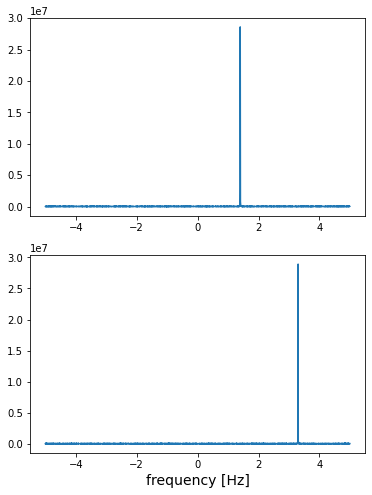

6703326.132029066


In [12]:
%matplotlib inline
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].plot(fft_freq, svd_results[1,:,0])
ax[1].plot(fft_freq, svd_results[4000,:,0])
ax[1].set_xlabel('frequency [Hz]', fontsize=14)
plt.show()
print(svd_results[4000,point_ind_1-1,0])